### Step-by-Step Implementation of Singular Value Decomposition (SVD)
Understanding the Implementation Steps
- Compute AᵀA and its eigenvectors (gives us V)
- Compute AAᵀ and its eigenvectors (gives us U)
- Calculate singular values (σ) from eigenvalues
- Sort everything in descending order of singular values
- Handle rectangular matrices properly
- Optional truncation for reduced-rank approximation

In [1]:
import numpy as np

def simple_svd(A):
    """
    Straightforward SVD implementation showing the fundamental steps
    Returns U, Σ (as array), Vᵀ
    """
    # Step 1: Compute both AᵀA and AAᵀ
    ATA = A.T @ A  # For V
    AAT = A @ A.T  # For U
    
    # Step 2: Compute eigenvalues/vectors for both
    eigvals_V, V = np.linalg.eigh(ATA)
    eigvals_U, U = np.linalg.eigh(AAT)
    
    # Step 3: Sort in descending order (same order for both!)
    idx = eigvals_V.argsort()[::-1]  # Get sorting indices
    eigvals_V = eigvals_V[idx]
    V = V[:, idx]
    
    idx = eigvals_U.argsort()[::-1]
    eigvals_U = eigvals_U[idx]
    U = U[:, idx]
    
    # Step 4: Get singular values (σ) from either set of eigenvalues
    sigma = np.sqrt(np.maximum(eigvals_V, 0))  # Using AᵀA's eigenvalues
    
    # Step 5: Keep only positive singular values
    pos_mask = sigma > 1e-10
    sigma = sigma[pos_mask]
    U = U[:, pos_mask]
    V = V[:, pos_mask]
    
    return U, sigma, V.T

In [42]:
A = np.array([[3, 1], 
              [1, 3]])
print(f"Original matrix A:\n{A}") 
U, S, Vt = simple_svd(A)
print(f"\nU matrix:\n{U}")
print(f"\nSingular values:\n{S}")
print(f"\nVt matrix:\n{Vt}")

# Verify reconstruction
reconstructed = U @ np.diag(S) @ Vt
print(f"\nReconstructed matrix:\n{reconstructed}")

Original matrix A:
[[3 1]
 [1 3]]

U matrix:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Singular values:
[4. 2.]

Vt matrix:
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Reconstructed matrix:
[[3. 1.]
 [1. 3.]]


## Shape Optimization Explained ("Tall vs Wide")
- Tall Matrices (m ≥ n) - The "Shoe" Case
- Wide Matrices (m < n) - The "All" Case

In [3]:
def improved_svd(A, k=None, tol=1e-10):
    m, n = A.shape
    
    # Special case for vectors/scalars
    if min(m, n) <= 1:
        return np.linalg.svd(A, full_matrices=False)
    
    # SHAPE-DEPENDENT COMPUTATION
    if m >= n:  # TALL matrix (shoe)
        # Compute smaller AᵀA (n×n)
        ATA = A.T @ A
        eigenvalues, V = np.linalg.eigh(ATA)
        
        # Sort and filter
        idx = eigenvalues.argsort()[::-1]
        eigenvalues = np.maximum(eigenvalues[idx], 0)
        sigma = np.sqrt(eigenvalues)
        pos_mask = sigma > tol
        
        # Get V and compute U
        V = V[:, idx][:, pos_mask]
        U = A @ V / sigma[pos_mask]
        
    else:  # WIDE matrix (all)
        # Compute smaller AAᵀ (m×m)
        AAT = A @ A.T
        eigenvalues, U = np.linalg.eigh(AAT)
        
        # Sort and filter
        idx = eigenvalues.argsort()[::-1]
        eigenvalues = np.maximum(eigenvalues[idx], 0)
        sigma = np.sqrt(eigenvalues)
        pos_mask = sigma > tol
        
        # Get U and compute Vᵀ directly
        U = U[:, idx][:, pos_mask]
        Vt = (U.T @ A) / sigma[pos_mask, np.newaxis]
        return U, sigma[pos_mask], Vt
    
    # Truncation for both cases
    if k is not None:
        k = min(k, len(sigma))
        sigma = sigma[:k]
        U = U[:, :k]
        V = V[:, :k]
    
    return U, sigma, V.T

In [ ]:
# Tall matrix example (shoe)
A_tall = np.random.rand(100, 5)  # 100 rows, 5 columns
U, S, Vt = improved_svd(A_tall)

In [ ]:
# Wide matrix example (all)
A_wide = np.random.rand(5, 100)  # 5 rows, 100 columns 
U, S, Vt = improved_svd(A_wide)

## Why This Optimization Matters

### Computational Efficiency:
- For a 1000×10 matrix (tall/shoe):
  - AᵀA is 10×10 (cheap to compute)
  - AAᵀ would be 1000×1000 (expensive)
- For a 10×1000 matrix (wide/all):
  - AAᵀ is 10×10 (cheap)
  - AᵀA would be 1000×1000 (expensive)
### Numerical Stability:
- Working with the smaller product matrix reduces floating-point errors
- The eigenvalues will be identical (up to zeros) for both approaches

### Let's use SVD for a practical image compression example

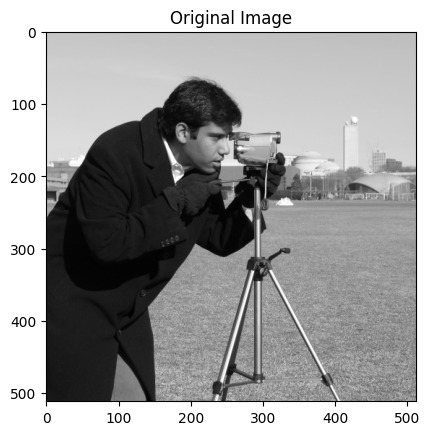

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Load a sample grayscale image (e.g., "camera" from skimage)
image = data.camera()
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.show()

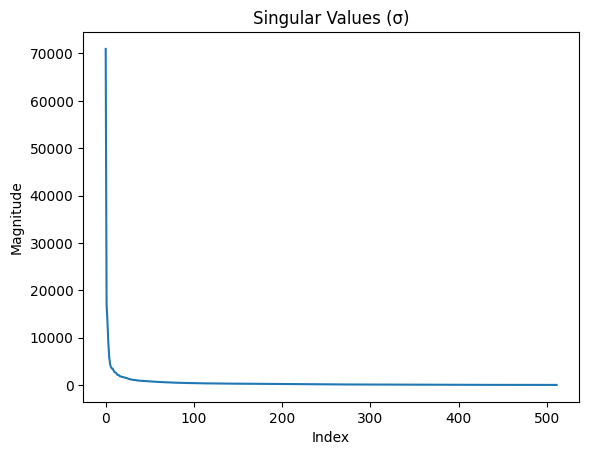

In [34]:
# Perform SVD
U, S, Vt = np.linalg.svd(image, full_matrices=False)

# Plot singular values (to decide compression level)
plt.plot(S)
plt.title("Singular Values (σ)")
plt.xlabel("Index")
plt.ylabel("Magnitude")
plt.show()

In [35]:
k = 100  # Keep top 50 components (adjust for quality/size tradeoff)
# Truncate U, S, Vt
U_k = U[:, :k]          # (512, 50)
S_k = S[:k]             # (50,)
Vt_k = Vt[:k, :]        # (50, 512)
# Reconstruct compressed image
compressed_image = U_k @ np.diag(S_k) @ Vt_k

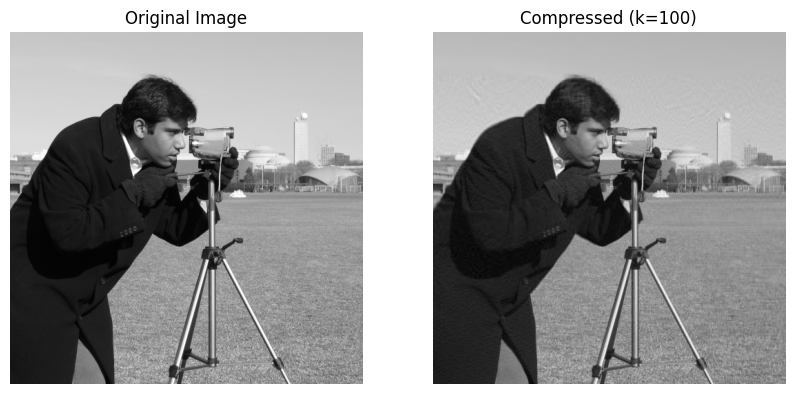

In [36]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(compressed_image, cmap='gray')
plt.title(f"Compressed (k={k})")
plt.axis('off')
plt.show()

### For colored Image

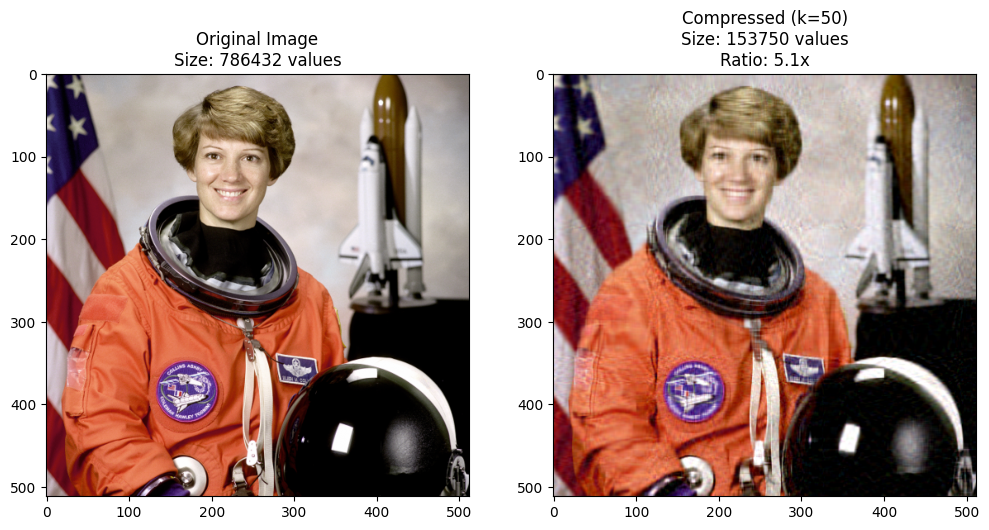

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# Load the astronaut image
image = data.astronaut()  # Shape (512, 512, 3)
image = img_as_float(image)  # Convert to float [0,1] range

# Compression parameters
k = 50  # Number of singular values to keep

# Initialize empty array for compressed image
compressed = np.zeros_like(image)

# Process each RGB channel separately
for channel in range(3):
    # Extract one color channel
    channel_data = image[:, :, channel]
    
    # Perform SVD on this channel
    U, S, Vt = np.linalg.svd(channel_data, full_matrices=False)
    
    # Truncate to top k components
    U_k = U[:, :k]          # Shape (512, k)
    S_k = S[:k]             # Shape (k,)
    Vt_k = Vt[:k, :]        # Shape (k, 512)
    
    # Reconstruct channel
    reconstructed_channel = U_k @ np.diag(S_k) @ Vt_k
    
    # Store in output array
    compressed[:, :, channel] = reconstructed_channel

# Clip values to valid range [0,1] and convert back to uint8 for display
compressed = np.clip(compressed, 0, 1)

# Calculate compression ratio
original_size = image.size
compressed_size = 3 * (U_k.size + S_k.size + Vt_k.size)  # 3 channels
compression_ratio = original_size / compressed_size
# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original Image\nSize: {original_size} values")
plt.subplot(1, 2, 2)
plt.imshow(compressed)
plt.title(f"Compressed (k={k})\nSize: {compressed_size} values\nRatio: {compression_ratio:.1f}x")
plt.show()

### Color Images Have 3 Channels (RGB)
- The astronaut image has shape (512, 512, 3) (height, width, RGB channels).
- If you tried to apply SVD directly to the 3D array without separating the channels, NumPy would fail because SVD expects a 2D matrix.

### Key Takeaways

- SVD works on 2D matrices only
  -  Grayscale: Directly apply SVD to (height, width).
  - Color: Apply SVD separately to each (height, width) channel (R, G, B).
- Why the Error Occurred
  - The code likely tried to treat the 3-channel image as a single matrix, causing dimension mismatches when multiplying (...,3) with (...,50).
- How to Avoid It
  - Always split color images into channels before SVD.
  - Ensure matrix dimensions align during reconstruction ((512,k) @ (k,k) @ (k,512)).

In [39]:
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer

# Step 1: Create user–item ratings matrix
ratings_dict = {
    'User1': [5, 3, 0, 1],
    'User2': [4, 0, 0, 1],
    'User3': [1, 1, 0, 5],
    'User4': [1, 0, 0, 4],
    'User5': [0, 1, 5, 4]
}

ratings_df = pd.DataFrame(ratings_dict, index=['Item1', 'Item2', 'Item3', 'Item4']).T
print("🎯 Original Ratings Matrix:\n", ratings_df)

# Step 2: Replace 0s with row-wise mean (user-based imputation)
imputer = SimpleImputer(missing_values=0, strategy='mean')
X_filled = imputer.fit_transform(ratings_df)

# Step 3: Apply Truncated SVD (reduce to k latent features)
svd = TruncatedSVD(n_components=2, random_state=42)  # you can try k=2, 3, ...
X_reduced = svd.fit_transform(X_filled)

# Step 4: Reconstruct full ratings matrix from SVD
X_reconstructed = svd.inverse_transform(X_reduced)

# Convert back to DataFrame
reconstructed_df = pd.DataFrame(X_reconstructed, index=ratings_df.index, columns=ratings_df.columns)
print("\n🧠 Reconstructed Ratings (predicted):\n", reconstructed_df.round(2))

# Step 5: Recommend items for a user
user_id = 'User2'

# Original ratings
user_original = ratings_df.loc[user_id]
# Predicted ratings
user_predicted = reconstructed_df.loc[user_id]

# Recommend items not already rated
recommendations = user_predicted[user_original == 0].sort_values(ascending=False)

print(f"\n📌 Top Recommendations for {user_id}:\n")
for item, score in recommendations.items():
    print(f"Recommend {item} (predicted rating: {score:.2f})")


🎯 Original Ratings Matrix:
        Item1  Item2  Item3  Item4
User1      5      3      0      1
User2      4      0      0      1
User3      1      1      0      5
User4      1      0      0      4
User5      0      1      5      4

🧠 Reconstructed Ratings (predicted):
        Item1  Item2  Item3  Item4
User1   5.03   2.54   5.21   0.87
User2   4.08   2.12   4.67   1.23
User3   0.96   1.01   5.04   4.97
User4   1.42   1.15   4.81   4.21
User5   2.30   1.53   5.22   3.76

📌 Top Recommendations for User2:

Recommend Item3 (predicted rating: 4.67)
Recommend Item2 (predicted rating: 2.12)
